# Single Galaxy Dispersion Demo

This notebook demonstrates how to disperse a single galaxy through the Roman grism using the disperser module.

We'll:
1. Create a synthetic galaxy with an exponential profile
2. Create a flat spectrum from 1-2 microns
3. Disperse the galaxy through multiple spectral orders
4. Visualize the dispersed spectra on the detector

The galaxy image uses 3× oversampling (50×50 native pixels → 150×150 input array) to better represent the sub-pixel structure.

In [1]:
# Imports
import os
from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.patches import Rectangle
import jax
import jax.numpy as jnp

from roman_disperser.optical_model import RomanOpticalModel
import roman_disperser.optical_model_jax as omj
import roman_disperser.disperser as disperser
import roman_disperser.demo_utils as demo_utils

# Use larger fonts for better readability
plt.rcParams['font.size'] = 11

## Configuration

Set the key parameters for the simulation. You can modify these values to explore different configurations.

In [2]:
# ============================================================================
# CONFIGURATION - Modify these parameters as needed
# ============================================================================

# Detector and spectral orders
SCA = 5                          # SCA number (1-18)
ORDERS = ["1", "0", "2"]         # Spectral orders to disperse

# Galaxy position on detector (SCA pixels, FITS 1-indexed)
X0 = 2044.0                      # X position (center of detector)
Y0 = 2044.0                      # Y position (center of detector)

# Galaxy parameters
HALF_LIGHT_RADIUS = 0.3          # Half-light radius in arcsec
NPIX_NATIVE = 50                 # Native pixels per side
OVERSAMPLE = 3                   # Oversampling factor

# Spectral parameters
LAM_MIN = 1.0                    # Minimum wavelength (microns)
LAM_MAX = 2.0                    # Maximum wavelength (microns)
N_WAVELENGTH = 1000              # Number of wavelength samples

# Computational parameters
WAVELENGTH_CHUNK_SIZE = 100      # Wavelengths processed per chunk (memory vs speed)

print(f"Configuration:")
print(f"  SCA: {SCA}")
print(f"  Orders: {ORDERS}")
print(f"  Galaxy position: ({X0:.1f}, {Y0:.1f}) SCA pixels")
print(f"  Galaxy size: {NPIX_NATIVE}×{NPIX_NATIVE} native pixels, {OVERSAMPLE}× oversampled")
print(f"  Input image: {NPIX_NATIVE * OVERSAMPLE}×{NPIX_NATIVE * OVERSAMPLE} pixels")
print(f"  Half-light radius: {HALF_LIGHT_RADIUS} arcsec")
print(f"  Spectrum: {N_WAVELENGTH} samples from {LAM_MIN}-{LAM_MAX} microns")

Configuration:
  SCA: 5
  Orders: ['1', '0', '2']
  Galaxy position: (2044.0, 2044.0) SCA pixels
  Galaxy size: 50×50 native pixels, 3× oversampled
  Input image: 150×150 pixels
  Half-light radius: 0.3 arcsec
  Spectrum: 1000 samples from 1.0-2.0 microns


## Load Optical Model

Load the Roman grism optical model configuration.

In [3]:
# Load optical model
project_root = Path(os.environ["PIXI_PROJECT_ROOT"])
config_path = project_root / "data" / "Roman_grism_OpticalModel_v0.8.yaml"

model = RomanOpticalModel(config_file=str(config_path))
pixel_scale = model.detmod["pixel_scale"]
print(f"Loaded optical model from {config_path.name}")
print(f"  Pixel scale: {pixel_scale} arcsec/pixel")
print(f"  Detector size: {model.detmod["naxis1"]}×{model.detmod["naxis2"]} pixels")
print(f"  Wavelength range: {model.wl_min:.2f}-{model.wl_max:.2f} microns")

Loaded optical model from Roman_grism_OpticalModel_v0.8.yaml
  Pixel scale: 0.11 arcsec/pixel
  Detector size: 4088×4088 pixels
  Wavelength range: 0.90-2.00 microns


## Create Galaxy Image

Generate a 2D exponential profile galaxy (Sersic n=1) with the specified half-light radius.
The image is normalized to have total flux = 1.0.

Galaxy image shape: (150, 150)
Total flux: 0.999999
Peak flux: 5.791132e-03


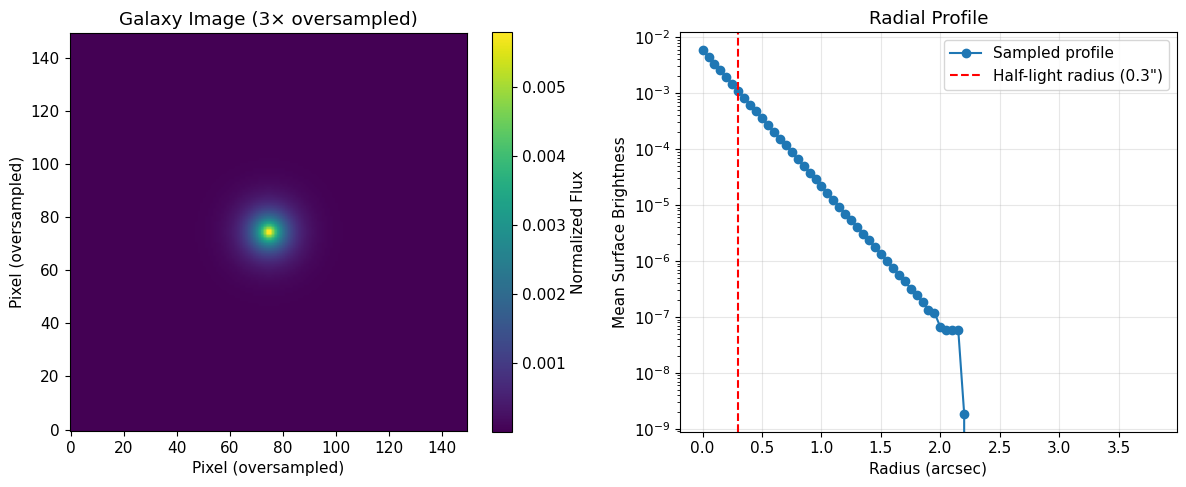

In [4]:
# Create exponential galaxy profile
galaxy_image = demo_utils.make_exponential_galaxy(
    npix=NPIX_NATIVE,
    half_light_radius_arcsec=HALF_LIGHT_RADIUS,
    pixel_scale_arcsec=pixel_scale,
    oversample=OVERSAMPLE,
    normalize=True,
)

print(f"Galaxy image shape: {galaxy_image.shape}")
print(f"Total flux: {float(galaxy_image.sum()):.6f}")
print(f"Peak flux: {float(galaxy_image.max()):.6e}")

# Visualize galaxy profile
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 2D image
ax = axes[0]
im = ax.imshow(galaxy_image, origin='lower', cmap='viridis')
ax.set_title('Galaxy Image (3× oversampled)')
ax.set_xlabel('Pixel (oversampled)')
ax.set_ylabel('Pixel (oversampled)')
plt.colorbar(im, ax=ax, label='Normalized Flux')

# Radial profile
ax = axes[1]
center = (galaxy_image.shape[0] - 1) / 2.0
y, x = np.mgrid[0:galaxy_image.shape[0], 0:galaxy_image.shape[1]]
r_pix = np.sqrt((x - center)**2 + (y - center)**2)
r_arcsec = r_pix * pixel_scale / OVERSAMPLE

# Bin radial profile
r_bins = np.arange(0, r_arcsec.max(), 0.05)
profile, _ = np.histogram(r_arcsec.ravel(), bins=r_bins, weights=galaxy_image.ravel())
counts, _ = np.histogram(r_arcsec.ravel(), bins=r_bins)
profile = profile / np.maximum(counts, 1)

ax.plot(r_bins[:-1], profile, 'o-', label='Sampled profile')
ax.axvline(HALF_LIGHT_RADIUS, color='r', linestyle='--', label=f'Half-light radius ({HALF_LIGHT_RADIUS}")')
ax.set_xlabel('Radius (arcsec)')
ax.set_ylabel('Mean Surface Brightness')
ax.set_title('Radial Profile')
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Create Flat Spectrum

Generate a flat (constant flux density) spectrum from 1-2 microns.

The units for this spectrum are arbitrary. Note however that the spectrum here is not normalized. 
In a real application, the spectrum would be normalized to have a given flux in a particular bandpass.

Spectrum shape: (1000,)
Total flux: 1000.000000
Wavelength range: 1.000 - 1.999 microns
Wavelength spacing: 0.001000 microns


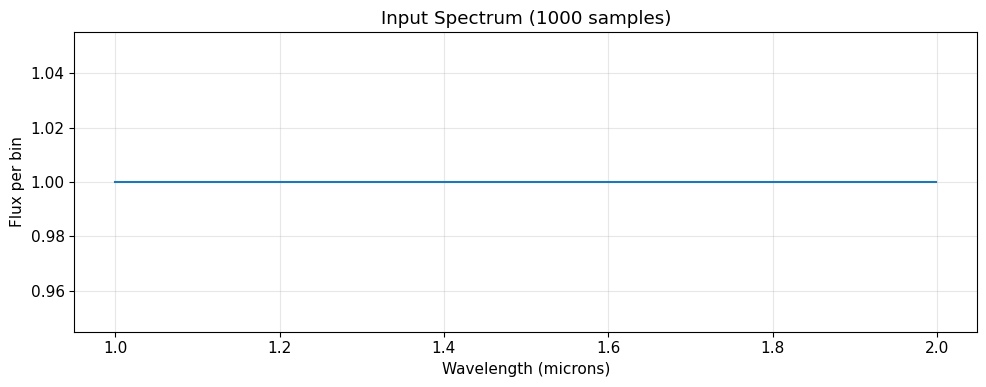

In [5]:
# Create flat spectrum
spectrum, lam0, dlam = demo_utils.make_flat_spectrum(
    lam_min=LAM_MIN,
    lam_max=LAM_MAX,
    n_wavelength=N_WAVELENGTH,
    normalize=False,
)

wavelengths = lam0 + np.arange(N_WAVELENGTH) * dlam

print(f"Spectrum shape: {spectrum.shape}")
print(f"Total flux: {float(spectrum.sum()):.6f}")
print(f"Wavelength range: {wavelengths[0]:.3f} - {wavelengths[-1]:.3f} microns")
print(f"Wavelength spacing: {dlam:.6f} microns")

# Visualize spectrum
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(wavelengths, spectrum, '-')
ax.set_xlabel('Wavelength (microns)')
ax.set_ylabel('Flux per bin')
ax.set_title(f'Input Spectrum ({N_WAVELENGTH} samples)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Disperse Galaxy Through Multiple Orders

Now we'll disperse the galaxy through each spectral order and accumulate the results on the detector.

The `disperse_2d1d_sca` function:
- Takes a 2D spatial image and 1D spectrum as input
- Uses the optical model to trace each spatial pixel through each wavelength
- Accumulates flux onto the detector using bilinear interpolation
- Processes wavelengths in chunks to limit memory usage

NOTE: We are passing in the original spectrum here for all orders, but for a real application, you would also need to scale the spectrum by the appropriate sensitivity curve.

In [6]:
# Pixel spacing for oversampled input
dx = 1.0 / OVERSAMPLE
dy = 1.0 / OVERSAMPLE

# Storage for dispersed images per order
dispersed_images = {}
timing_info = {}

print("Dispersing galaxy through spectral orders...\n")

for order in ORDERS:
    print(f"Processing order {order}...")
    
    # Create payload for this SCA and order
    payload = omj.make_sca_payload(model, sca=SCA, order=order)
    
    # Initialize output detector
    output = jnp.zeros((4088, 4088), dtype=jnp.float32)
    
    # Disperse galaxy (time it)
    t0 = time.time()
    
    output = disperser.disperse_2d1d_sca(
        payload=payload,
        image=galaxy_image,
        x0=X0,
        y0=Y0,
        dx=dx,
        dy=dy,
        spec=spectrum,
        lam0=lam0,
        dlam=dlam,
        output=output,
        wavelength_chunk_size=WAVELENGTH_CHUNK_SIZE,
    )
    
    # Block until computation is done (JAX is lazy)
    output.block_until_ready()
    
    elapsed = time.time() - t0
    
    # Compute flux conservation
    metrics = demo_utils.compute_flux_conservation(galaxy_image, spectrum, output)
    
    # Store results
    dispersed_images[order] = output
    timing_info[order] = elapsed
    
    print(f"  Time: {elapsed:.3f} seconds")
    print(f"  Input flux: {metrics['input_flux']:.6f}")
    print(f"  Output flux: {metrics['output_flux']:.6f}")
    print(f"  Conservation: {metrics['conservation_percent']:.2f}%")
    print()

print("Dispersion complete!")

Dispersing galaxy through spectral orders...

Processing order 1...
  Time: 0.627 seconds
  Input flux: 999.999023
  Output flux: 999.998169
  Conservation: 100.00%

Processing order 0...
  Time: 0.621 seconds
  Input flux: 999.999023
  Output flux: 999.973328
  Conservation: 100.00%

Processing order 2...
  Time: 0.381 seconds
  Input flux: 999.999023
  Output flux: 947.580750
  Conservation: 94.76%

Dispersion complete!


## Visualize Dispersed Spectra

Display the dispersed spectra for each order. Two layout options are provided below - you can choose which one works better for your use case.

**Option 1 (Side-by-side)**: Full detector view and zoom view side-by-side for each order. Good for seeing the full context. Improved spacing and cleaner tick labels compared to the original.

**Option 2 (Stacked)**: All full detector views in one row, all zoomed views in another row. More compact and easier to compare across orders.

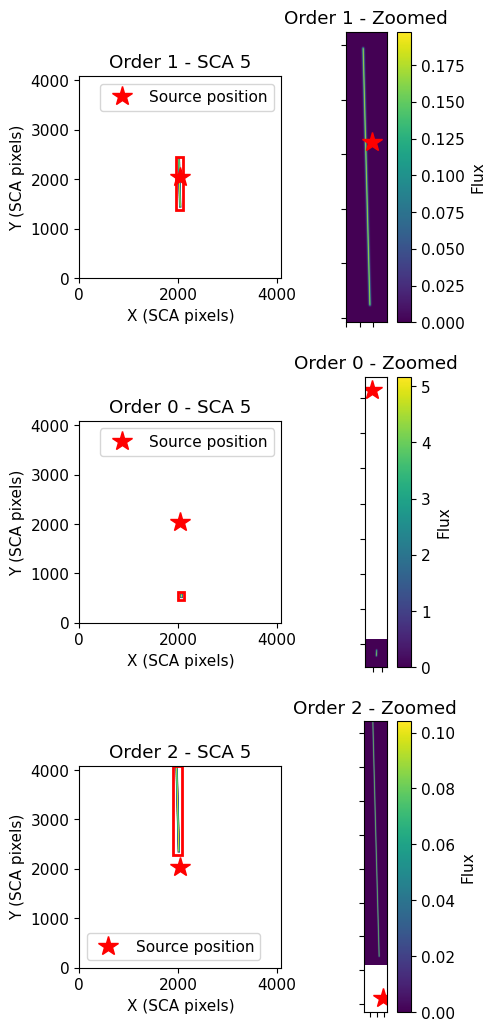

In [11]:
# Option 1: Side-by-side layout (improved spacing)

# Create figure with subplots for each order
fig, axes = plt.subplots(len(ORDERS), 2, figsize=(5, 3.5 * len(ORDERS)))
if len(ORDERS) == 1:
    axes = axes.reshape(1, -1)

for idx, order in enumerate(ORDERS):
    output = dispersed_images[order]
    
    # Get bounding box for zoomed view
    y_min, y_max, x_min, x_max = demo_utils.get_dispersed_extent(
        output, threshold_fraction=0.001
    )
    
    # Add padding
    pad = 50
    y_min = max(0, y_min - pad)
    y_max = min(4087, y_max + pad)
    x_min = max(0, x_min - pad)
    x_max = min(4087, x_max + pad)
    
    # Full detector view (LEFT COLUMN)
    ax = axes[idx, 0]
    im = ax.imshow(
        output,
        origin='lower',
        cmap='viridis',
        norm=plt.matplotlib.colors.LogNorm(vmin=1e-8, vmax=output.max()),
    )
    ax.set_title(f'Order {order} - SCA {SCA}')
    ax.set_xlabel('X (SCA pixels)')
    ax.set_ylabel('Y (SCA pixels)')
    
    # Draw box showing zoomed region
    rect = Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        fill=False,
        edgecolor='red',
        linewidth=2,
    )
    ax.add_patch(rect)
    
    # Mark source position
    ax.plot(X0, Y0, 'r*', markersize=15, label='Source position')
    ax.legend()
    
    # Zoomed view (RIGHT COLUMN)
    ax = axes[idx, 1]
    zoomed = output[y_min:y_max+1, x_min:x_max+1]
    im = ax.imshow(
        zoomed,
        origin='lower',
        cmap='viridis',
        extent=[x_min, x_max, y_min, y_max],
    )
    ax.set_title(f'Order {order} - Zoomed')
    
    # Remove tick labels to reduce clutter
    ax.tick_params(labelbottom=False, labelleft=False)
    
    plt.colorbar(im, ax=ax, label='Flux')
    
    # Mark source position
    ax.plot(X0, Y0, 'r*', markersize=15)

plt.tight_layout(h_pad=1.5, w_pad=2.0)
plt.show()

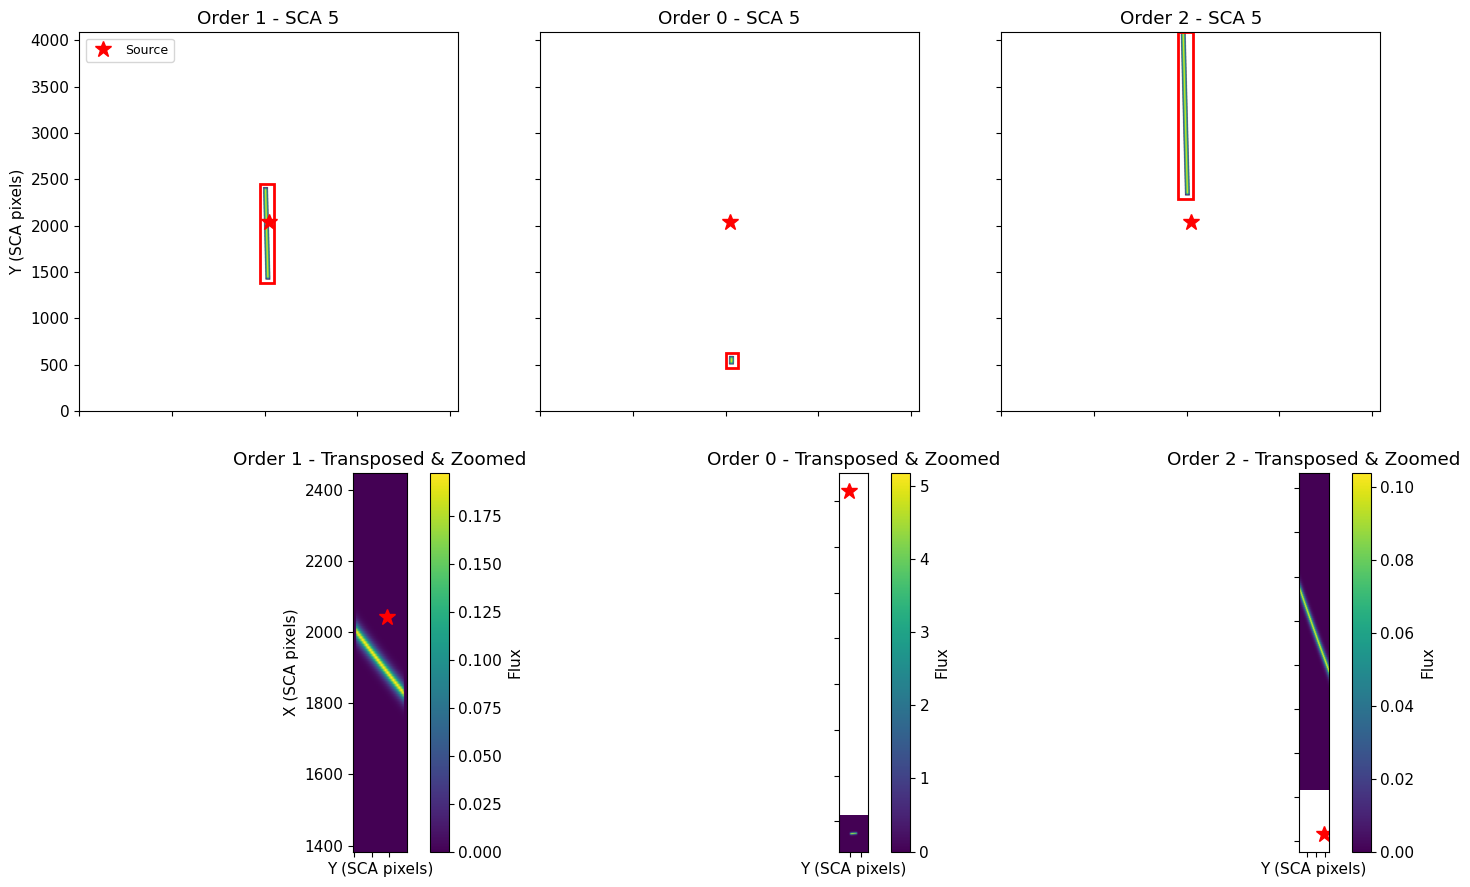

In [ ]:
# Option 2: Stacked layout (compact, easy to compare)

# Create figure with stacked layout
n_orders = len(ORDERS)
fig, axes = plt.subplots(2, n_orders, figsize=(5 * n_orders, 9))
if n_orders == 1:
    axes = axes.reshape(2, 1)

# Collect zoom extents for all orders first
zoom_extents = {}
for order in ORDERS:
    output = dispersed_images[order]
    y_min, y_max, x_min, x_max = demo_utils.get_dispersed_extent(
        output, threshold_fraction=0.001
    )
    pad = 50
    zoom_extents[order] = (
        max(0, y_min - pad),
        min(4087, y_max + pad),
        max(0, x_min - pad),
        min(4087, x_max + pad)
    )

# Plot full detector views (TOP ROW)
for idx, order in enumerate(ORDERS):
    output = dispersed_images[order]
    y_min, y_max, x_min, x_max = zoom_extents[order]
    
    ax = axes[0, idx]
    im = ax.imshow(
        output,
        origin='lower',
        cmap='viridis',
        norm=plt.matplotlib.colors.LogNorm(vmin=1e-8, vmax=output.max()),
    )
    ax.set_title(f'Order {order} - SCA {SCA}')
    
    # Only show y-axis labels on leftmost plot
    if idx == 0:
        ax.set_ylabel('Y (SCA pixels)')
    else:
        ax.tick_params(labelleft=False)
    
    # No x-axis labels on top row
    ax.tick_params(labelbottom=False)
    
    # Draw zoom box
    rect = Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        fill=False,
        edgecolor='red',
        linewidth=2,
    )
    ax.add_patch(rect)
    
    # Mark source position
    ax.plot(X0, Y0, 'r*', markersize=12, label='Source' if idx == 0 else '')
    if idx == 0:
        ax.legend(loc='upper left', fontsize=9)

# Plot zoomed views (BOTTOM ROW - ROTATED)
for idx, order in enumerate(ORDERS):
    output = dispersed_images[order]
    y_min, y_max, x_min, x_max = zoom_extents[order]
    
    ax = axes[1, idx]
    zoomed = output[y_min:y_max+1, x_min:x_max+1]
    
    # Rotate image 90 degrees counter-clockwise
    zoomed_rotated = np.rot90(zoomed)
    
    im = ax.imshow(
        zoomed_rotated,
        origin='lower',
        cmap='viridis',
    )
    
    # No individual titles for bottom row
    
    # Only show y-axis label on leftmost plot
    if idx == 0:
        ax.set_ylabel('Zoomed and Rotated', fontsize=12, fontweight='bold')
    
    # Remove tick labels for cleaner look
    ax.tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)
    
    # Horizontal colorbar below each zoomed image
    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, label='Flux')

plt.tight_layout(h_pad=2.0, w_pad=1.5)
plt.show()

## Summary Statistics

Display summary information about the dispersion results.

In [ ]:
print("="*60)
print("DISPERSION SUMMARY")
print("="*60)
print(f"\nConfiguration:")
print(f"  SCA: {SCA}")
print(f"  Galaxy position: ({X0:.1f}, {Y0:.1f}) SCA pixels")
print(f"  Input image: {galaxy_image.shape}")
print(f"  Input spectrum: {spectrum.shape[0]} wavelengths")

print(f"\nResults by Order:")
for order in ORDERS:
    output = dispersed_images[order]
    metrics = demo_utils.compute_flux_conservation(galaxy_image, spectrum, output)
    
    print(f"\n  Order {order}:")
    print(f"    Computation time: {timing_info[order]:.3f} s")
    print(f"    Flux conservation: {metrics['conservation_percent']:.2f}%")
    print(f"    Peak flux: {float(output.max()):.6e}")
    print(f"    Total flux: {float(output.sum()):.6f}")

print(f"\nTotal time: {sum(timing_info.values()):.3f} seconds")
print("="*60)

## Notes

- **Flux conservation**: Some flux may be lost if the dispersed spectrum extends beyond the detector boundaries. For sources near the center, conservation should be close to 100%.

- **Performance**: The first run may be slower due to JAX compilation. Subsequent runs with the same array shapes will be faster.

- **Memory usage**: The wavelength chunking strategy keeps memory usage low (~100-200 MB) even for large wavelength arrays.

- **Oversampling**: The 3× oversampling ensures smooth representation of the sub-pixel galaxy structure. Try changing `OVERSAMPLE` to see the effect.

- **Orders**: Different spectral orders disperse in different directions and with different amounts. Order "1" is typically the primary science order.